In [1]:
import pandas as pd
import numpy as np
import networkx as nx
from itertools import combinations, product
import matplotlib.pyplot as plt
import seaborn as sns
import copy
import os

from tqdm import tqdm
from sdv.metadata import SingleTableMetadata
from sdv.single_table import CopulaGANSynthesizer, TVAESynthesizer, CTGANSynthesizer
from sklearn.metrics import r2_score
from scipy.interpolate import CubicSpline, PchipInterpolator, Akima1DInterpolator

import torch
import torch.nn as nn
import torch.optim as optim
from scipy.optimize import minimize
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.api import ExponentialSmoothing


device = torch.device('cpu')

# plt.style.use('ggplot')
plt.style.use('default')

import matplotlib as mpl
#set params for the article
mpl.rcParams['xtick.labelsize'] = 16
mpl.rcParams['ytick.labelsize'] = 16
mpl.rcParams['legend.fontsize'] = 14
mpl.rcParams['axes.labelsize'] = 18

#set params for the notebook
# mpl.rcParams['xtick.labelsize'] = 12
# mpl.rcParams['ytick.labelsize'] = 12
# mpl.rcParams['legend.fontsize'] = 10
# mpl.rcParams['axes.labelsize'] = 14


# import category_encoders as ce

In [2]:
data = pd.read_csv('train_data.csv')

In [3]:
data = data.drop(['Этаж', 'Район', 'id', 'date', 'rooms', 'Цена', 'nprice'], axis=1)
data['day'] = pd.to_datetime(data['day'])
data['month'] = data['day'].dt.month
data['year'] = data['day'].dt.year
data['day'] = data['day'].dt.day

data = data.drop(['day', 'month', 'year'], axis=1)

In [4]:
data = data.dropna()

In [5]:
data.shape

(251607, 24)

In [6]:
data.head()

,Площадь квартиры,количество этажей всего,высота объекта,Этажность объекта подземная,Этажность объекта наземная,Количество квартир,Общая площадь объекта,Площадь жилых помещений объекта,lon,lat,...,medprox,kidprox,schoolprox,cemetprox,industrprox,daysin,daycos,liveratio,highratio,pricemetr
0,19.8,26.0,76.71,1.0,25.0,1056.0,76762.2,52066.5,37.348298,55.801606,...,0.013206,0.001609,0.001643,0.025956,0.018132,-0.936881,-0.349647,0.678283,3.068400,0.295860
1,50.8,26.0,76.71,1.0,25.0,1056.0,76762.2,52066.5,37.348298,55.801606,...,0.013206,0.001609,0.001643,0.025956,0.018132,-0.972118,-0.234491,0.678283,3.068400,0.217977
2,43.2,18.0,54.55,1.0,13.0,609.0,48074.8,34516.4,37.319359,55.638227,...,0.011027,0.001051,0.005334,0.044600,0.010277,0.247022,-0.969010,0.717973,4.196154,0.214741
3,39.7,18.0,54.55,1.0,13.0,609.0,48074.8,34516.4,37.319359,55.638227,...,0.011027,0.001051,0.005334,0.044600,0.010277,0.213521,-0.976938,0.717973,4.196154,0.223181
4,83.2,18.0,54.55,1.0,13.0,609.0,48074.8,34516.4,37.319359,55.638227,...,0.011027,0.001051,0.005334,0.044600,0.010277,0.213521,-0.976938,0.717973,4.196154,0.182830


In [7]:
data = pd.concat([data.drop('pricemetr', axis=1), data['pricemetr']], axis=1)

In [8]:
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_percentage_error, r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [9]:
def train(X: pd.DataFrame, y: pd.Series, model):
    mape_arr = []
    r2_arr = []
    
    for _ in range(5):
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
        
        model.fit(X_train, y_train)
        prediction = model.predict(X_test)
        
        mape_arr.append(mean_absolute_percentage_error(y_test.values, prediction))
        r2_arr.append(r2_score(y_test.values, prediction))
        
    
    return {'mape_mean': round(np.mean(mape_arr), 3), 'mape_std': round(np.std(mape_arr), 4),\
            'r2_mean': round(np.mean(r2_arr), 3), 'r2_std': round(np.std(r2_arr), 4)}

In [10]:
X, y = data.drop('pricemetr', axis=1), data['pricemetr']

# xgb = XGBRegressor()

# train(X, y, xgb)

In [11]:
# model_list = zip([XGBRegressor(), RandomForestRegressor(), LinearRegression(), KNeighborsRegressor()], ['XGB', 'RF', 'LR', 'KNN'])

# for model, name in model_list:
#     print(name, train(X, y, model))

In [156]:
np.random.seed(55555)

X_ex1 = np.concatenate([np.random.uniform(0.0, 0.199, (100)), np.random.uniform(0.301, 0.599, (360)), np.random.uniform(0.701, 1.0, (340))]).reshape(-1, 1)
np.random.shuffle(X_ex1)

X_ex2 = np.concatenate([np.random.uniform(0.0, 0.999, (360)), np.random.uniform(0.301, 0.799, (340)), np.random.uniform(0.901, 1.0, (100))]).reshape(-1, 1)
np.random.shuffle(X_ex2)


X_ex = np.concatenate([X_ex1, X_ex2], axis=1)

X_ex = np.concatenate([X_ex, np.concatenate([np.random.uniform(0.2, 0.3, (30, 1)), np.random.uniform(0.0, 0.799, (30, 1))], axis=1)])
X_ex = np.concatenate([X_ex, np.concatenate([np.random.uniform(0.2, 0.3, (30, 1)), np.random.uniform(0.901, 1.0, (30, 1))], axis=1)])
X_ex = np.concatenate([X_ex, np.concatenate([np.random.uniform(0.6, 0.7, (30, 1)), np.random.uniform(0.0, 0.999, (30, 1))], axis=1)])
X_ex = np.concatenate([X_ex, np.concatenate([np.random.uniform(0.6, 0.7, (30, 1)), np.random.uniform(0.301, 1.0, (30, 1))], axis=1)])

y_ex = 2 * X_ex[:, 0] + 3 * X_ex[:, 1] + 4 + np.random.normal(0, 0.1, (1000 - 80))
# y_ex[np.random.randint(0, 1000, 10)] = y_ex[np.random.randint(0, 1000, 10)] + np.random.normal(0, 1, (10))
# y_ex[np.where((X_ex[:, 0] < 0.2) & (X_ex[:, 0] > 0.1))[0]] = y_ex[np.where((X_ex[:, 0] < 0.2) & (X_ex[:, 0] > 0.1))[0]] + np.random.normal(0, 2)


X_ex_b = np.concatenate([np.random.uniform(0.2, 0.3, (30, 1)), np.random.uniform(0.8, 0.9, (30, 1))], axis=1)
y_ex_b = 2 * X_ex_b[:, 0] + 8 * X_ex_b[:, 1] - 32
X_ex = np.concatenate([X_ex_b, X_ex])
y_ex = np.concatenate([y_ex_b, y_ex])

X_ex_b = np.concatenate([np.random.uniform(0.6, 0.7, (50, 1)), np.random.uniform(0.1, 0.3, (50, 1))], axis=1)
y_ex_b = 2 * X_ex_b[:, 0] - 3 * X_ex_b[:, 1] + 1
X_ex = np.concatenate([X_ex_b, X_ex])
y_ex = np.concatenate([y_ex_b, y_ex])


X_ex = pd.DataFrame(X_ex)
y_ex = pd.DataFrame(y_ex)

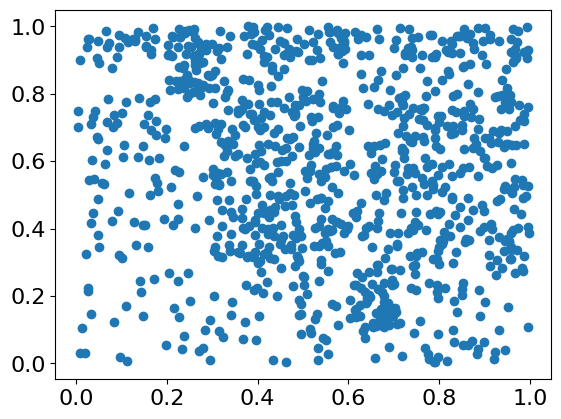

In [157]:
plt.scatter(X_ex.iloc[:, 0], X_ex.iloc[:, 1])
plt.show()

## Baseline

In [ ]:
scaler_X_train = MinMaxScaler()
scaler_y_train = MinMaxScaler()
# data = pd.DataFrame(scaler.fit_transform(data), columns=data.columns)

# X_train, X_test, y_train, y_test = train_test_split(data.drop('pricemetr', axis=1), data['pricemetr'], test_size=0.2, random_state=55555)
X_train, X_test, y_train, y_test = train_test_split(X_ex, y_ex, test_size=0.2, random_state=55555)

X_train = pd.DataFrame(scaler_X_train.fit_transform(X_train))
X_test = pd.DataFrame(scaler_X_train.transform(X_test))
y_train = pd.DataFrame(scaler_y_train.fit_transform(y_train.values.reshape(-1, 1)))
y_test = pd.DataFrame(scaler_y_train.transform(y_test.values.reshape(-1, 1)))


# xgb = XGBRegressor()
xgb = LinearRegression()

xgb.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [232]:
new_reg_model = XGBRegressor()
new_reg_model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [159]:
xgb_pred = xgb.predict(X_test)

In [160]:
mean_absolute_percentage_error(y_test.values, xgb_pred)

5.280418695991122

In [161]:
r2_score(y_test.values, xgb_pred)

0.07742417776977828

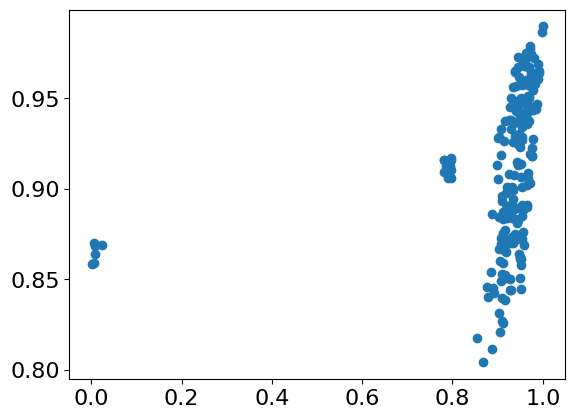

In [162]:
plt.scatter(y_test.values, xgb_pred)
# plt.plot(np.linspace(0, 0.6, 10), np.linspace(0, 0.6, 10), color='black')
plt.show()

## Select bad examples

In [163]:
def select_bad_examples(X: pd.DataFrame, y: pd.DataFrame, predictions: np.array, thrs: float = 0.05):
    idx_bad = np.where(np.abs(y.values.flatten() - predictions.flatten()) >= thrs)[0]
    bad_y = y.iloc[idx_bad]
    bad_X = X.iloc[idx_bad]
    
    return bad_X, bad_y

In [164]:
bad_X, bad_y = select_bad_examples(X_test, y_test, xgb_pred, 0.1)

In [165]:
# idx_bad = np.where(np.abs(y_test.values - xgb_pred) > 0.05)[0]
# bad_y = y_test.iloc[idx_bad]
# bad_X = X_test.loc[y_test.iloc[idx_bad].index]

In [166]:
bad_X.shape

(20, 2)

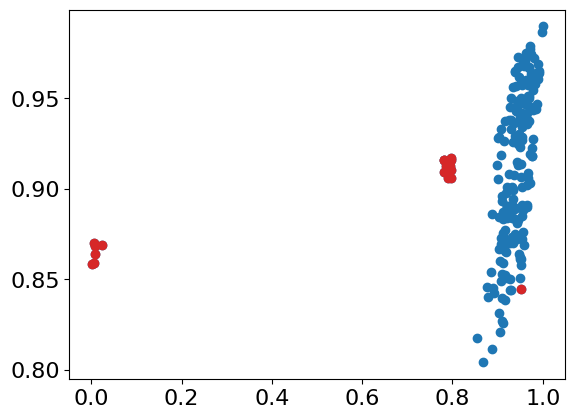

In [170]:
plt.scatter(y_test.values, xgb_pred, color='tab:blue')
plt.scatter(bad_y, xgb.predict(bad_X), color='tab:red')
plt.show()

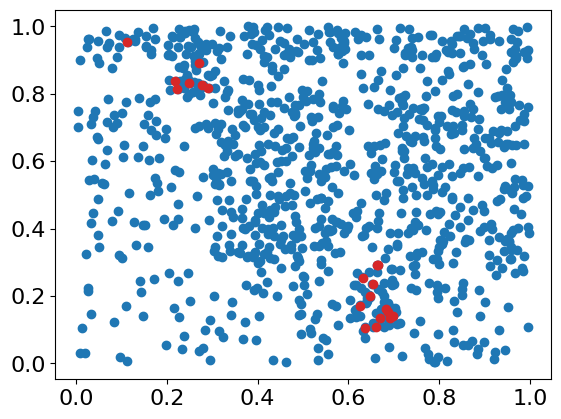

In [168]:
plt.scatter(X_ex.iloc[:, 0], X_ex.iloc[:, 1])
plt.scatter(bad_X.iloc[:, 0], bad_X.iloc[:, 1], color='tab:red')

plt.show()

In [1133]:
# bad_data = data.loc[bad_y.index]

In [75]:
from deap import base, creator, tools, algorithms
import random

In [1135]:
low = [0.0] * 10
up = [1.0] * 10
num1_copy = [0.3, 0.4, 0.4, 0.5, 0.1]
num2_copy = [0.1, 0.1, 0.8, 0.8, 0.9]

tools.cxTwoPoint(num1_copy, num2_copy)

([0.3, 0.4, 0.4, 0.8, 0.1], [0.1, 0.1, 0.8, 0.5, 0.9])

In [1136]:
tools.cxUniform(num1_copy, num2_copy, indpb= 0.4)

([0.1, 0.4, 0.4, 0.5, 0.1], [0.3, 0.1, 0.8, 0.8, 0.9])

In [1137]:
tools.cxUniform([0, 0, 1], [1, 0, 0], indpb= 0.4)

([1, 0, 1], [0, 0, 0])

In [171]:
length_cat_ordinal = 0
length_cat_onehot = []
# length_num = len(X.iloc[0])
length_num = 2

In [172]:
# import random
# from deap import tools

# def cxOneHotOX(ind1, ind2, feature_sizes):
#     """
#     Order-Based Crossover (OX) для OneHot-кодированных признаков.
    
#     Args:
#         ind1: первая особь (list)
#         ind2: вторая особь (list)
#         feature_sizes: список размеров каждого OneHot-блока
        
#     Returns:
#         Кортеж из двух особей с сохранением валидности OneHot-векторов
#     """
#     # Проверяем, что особи одинаковой длины
#     assert len(ind1) == len(ind2), "Особи должны быть одинаковой длины"
    
#     # Создаем копии для безопасности
#     child1 = ind1[:]
#     child2 = ind2[:]
    
#     # Определяем границы блоков
#     boundaries = []
#     start = 0
#     for size in feature_sizes:
#         end = start + size
#         boundaries.append((start, end))
#         start = end
    
#     # Для каждого признака (блока) применяем OX
#     for start, end in boundaries:
#         # Выбираем случайные точки разрыва в пределах блока
#         if end - start < 2:
#             continue  # Пропускаем блоки размером 1
            
#         a, b = random.sample(range(start, end), 2)
#         point1, point2 = min(a, b), max(a, b)
        
#         # Копируем сегменты между точками разрыва
#         segment1 = child1[point1:point2]
#         segment2 = child2[point1:point2]
        
#         # Создаем маски для определения позиций единиц
#         ones_pos1 = [i for i in range(start, end) if child1[i] == 1]
#         ones_pos2 = [i for i in range(start, end) if child2[i] == 1]
        
#         # Заменяем сегменты
#         child1[point1:point2] = segment2
#         child2[point1:point2] = segment1
        
#         # Восстанавливаем валидность OneHot-векторов
#         repair_onehot_block(child1, start, end, ones_pos1)
#         repair_onehot_block(child2, start, end, ones_pos2)
    
#     return child1, child2

# def repair_onehot_block(individual, start, end, original_ones_pos):
#     """
#     Восстанавливает валидность OneHot-блока после скрещивания.
#     """
#     block = individual[start:end]
    
#     # Проверяем сумму элементов в блоке
#     block_sum = sum(block)
    
#     if block_sum == 1:
#         return  # Блок уже валиден
    
#     if block_sum == 0:
#         # Если все элементы нулевые, восстанавливаем исходную позицию единицы
#         if original_ones_pos and start <= original_ones_pos[0] < end:
#             individual[original_ones_pos[0]] = 1
#         else:
#             # Или выбираем случайную позицию
#             pos = random.randint(start, end-1)
#             individual[pos] = 1
    
#     elif block_sum > 1:
#         # Если больше одной единицы, оставляем только одну
#         ones_positions = [i for i in range(start, end) if individual[i] == 1]
        
#         # Оставляем только первую единицу, остальные обнуляем
#         for i, pos in enumerate(ones_positions):
#             if i == 0:
#                 continue  # Первую единицу оставляем
#             individual[pos] = 0

# # Пример использования в DEAP
# toolbox.register("mate", cxOneHotOX, feature_sizes=[3, 4, 2])  # Пример: 3 признака с 3, 4 и 2 категориями

In [173]:
length_cat_onehot == []

True

In [174]:
def cxOneHotByFeature(ind1, ind2, feature_sizes):
    child1 = ind1[:]
    child2 = ind2[:]
    
    start = 0
    for size in feature_sizes:
        end = start + size
        if random.random() < 0.5:  # 50% chance to swap the feature
            child1[start:end], child2[start:end] = child2[start:end], child1[start:end]
        start = end
    
    return child1, child2

In [175]:
def custom_crossover_num(ind1, ind2, num_eta=10):
    num1_copy = copy.deepcopy(ind1)
    num2_copy = copy.deepcopy(ind1)

    low = [0.0] * len(num1_copy)
    up = [1.0] * len(num1_copy)
    tools.cxSimulatedBinaryBounded(num1_copy, num2_copy, eta=num_eta, low=low, up=up)

    ind1 = num1_copy
    ind2 = num2_copy

    return ind1, ind2


def custom_crossover_num_ord(ind1, ind2, cat_indpb=0.3, num_eta=10):
    cat1 = ind1[:length_cat_ordinal]
    cat2 = ind2[:length_cat_ordinal]
    num1 = ind1[length_cat_ordinal:]
    num2 = ind2[length_cat_ordinal:]

    cat1_copy = copy.deepcopy(list(cat1))
    cat2_copy = copy.deepcopy(list(cat2))
    num1_copy = copy.deepcopy(list(num1))
    num2_copy = copy.deepcopy(list(num2))

    tools.cxUniform(cat1_copy, cat2_copy, indpb=cat_indpb)

    low = [0.0] * len(num1_copy)
    up = [1.0] * len(num1_copy)
    tools.cxSimulatedBinaryBounded(num1_copy, num2_copy, eta=num_eta, low=low, up=up)

    ind1[:] = cat1_copy + num1_copy
    ind2[:] = cat2_copy + num2_copy

    return ind1, ind2


def custom_crossover_num_ord_nominal(ind1, ind2, cat_indpb=0.3, num_eta=10):
    onehot1 = ind1[:sum(length_cat_onehot)]
    onehot2 = ind2[:sum(length_cat_onehot)]
    cat1 = ind1[sum(length_cat_onehot) : sum(length_cat_onehot) + length_cat_ordinal]
    cat2 = ind2[sum(length_cat_onehot) : sum(length_cat_onehot) + length_cat_ordinal]
    num1 = ind1[-length_num:]
    num2 = ind2[-length_num:]

    cat1_copy = copy.deepcopy(list(cat1))
    cat2_copy = copy.deepcopy(list(cat2))
    num1_copy = copy.deepcopy(list(num1))
    num2_copy = copy.deepcopy(list(num2))

    tools.cxUniform(cat1_copy, cat2_copy, indpb=cat_indpb)

    low = [0.0] * len(num1_copy)
    up = [1.0] * len(num1_copy)
    tools.cxSimulatedBinaryBounded(num1_copy, num2_copy, eta=num_eta, low=low, up=up)

    ind1[:] = cat1_copy + num1_copy
    ind2[:] = cat2_copy + num2_copy

    return ind1, ind2

In [176]:
def custom_mutate_num(individual, weights, linear_coefs, target_direction, base_mutation_rate=0.8, mutation_strength=0.5):
    for i in range(len(individual)):
        mutation_prob = base_mutation_rate # * weights[i]
        
        if random.random() < mutation_prob:
            coef = linear_coefs[i]
            direction = 1 if coef * target_direction >= 0 else -1
            
            # noise = direction * abs(np.random.normal(0, weights[i] * mutation_strength))
            noise = direction * abs(np.random.normal(0, 0.1 * mutation_strength))
            individual[i] = max(0, min(1, individual[i] + noise))
                
    return individual,


# def custom_mutate(individual, weights, linear_coefs, target_direction, base_mutation_rate=0.8, mutation_strength=0.5):
#     for i in range(len(individual)):
#         mutation_prob = base_mutation_rate * weights[i]
        
#         if random.random() < mutation_prob:
#             if i < len(cat_cols_name): 
#                 individual[i] = random.sample(list(X_exp[cat_cols_name[i]].unique()), 1)[0]
#             else: 
#                 # idx = i - len(cat_cols_name)
#                 coef = linear_coefs[i]
                
#                 direction = 1 if coef * target_direction >= 0 else -1
                
#                 noise = direction * abs(np.random.normal(0, weights[i] * mutation_strength))
#                 individual[i] = max(0, min(1, individual[i] + noise))
                
#     return individual,


# def custom_mutate(individual, weights, linear_coefs, target_direction, base_mutation_rate=0.8, mutation_strength=0.5):
#     for i in range(len(individual)):
#         mutation_prob = base_mutation_rate * weights[i]
        
#         if random.random() < mutation_prob:
#             if i < len(cat_cols_name): 
#                 individual[i] = random.sample(list(X_exp[cat_cols_name[i]].unique()), 1)[0]
#             else: 
#                 # idx = i - len(cat_cols_name)
#                 coef = linear_coefs[i]
                
#                 direction = 1 if coef * target_direction >= 0 else -1
                
#                 noise = direction * abs(np.random.normal(0, weights[i] * mutation_strength))
#                 individual[i] = max(0, min(1, individual[i] + noise))
                
#     return individual,

In [177]:
lr = LinearRegression(fit_intercept=False)
lr.fit(X_train, y_train)
linear_coefs = lr.coef_[0]

In [178]:
cat_cols_name = []

In [281]:
creator.create("FitnessMax", base.Fitness, weights=(1.0,))
creator.create("Individual", list, fitness=creator.FitnessMax)
toolbox = base.Toolbox()


if (length_cat_ordinal == 0) and (length_cat_onehot == []):
    for i in range(length_num):
        # toolbox.register(f"num_{i}", random.uniform, 0.0, 1.0)
        toolbox.register(f"num_{i}", random.sample, list(bad_X.iloc[:, i].unique()), 1)
        
    def make_individual():
        return creator.Individual(np.hstack([toolbox.__getattribute__(f"num_{i}")() for i in range(length_num)]))
         
    toolbox.register("individual", tools.initIterate, creator.Individual, make_individual)
    toolbox.register("population", tools.initRepeat, list, toolbox.individual)
    toolbox.register("mate", custom_crossover_num)
        
        
elif (length_cat_ordinal != 0) and (length_cat_onehot == []):
    for i, col in enumerate(cat_cols_name):
        toolbox.register(f"cat_{i}", random.sample, list(X[col].unique()), 1)
        
    for i in range(length_num):
        toolbox.register(f"num_{i}", random.uniform, 0.0, 1.0)
        
    def make_individual():
        return np.hstack([toolbox.__getattribute__(f"cat_{i}")() for i in range(length_cat_ordinal)] + \
            [toolbox.__getattribute__(f"num_{i}")() for i in range(length_num)])
        
    toolbox.register("individual", tools.initIterate, creator.Individual, make_individual)
    toolbox.register("population", tools.initRepeat, list, toolbox.individual)
    toolbox.register("mate", custom_crossover_num_ord)
    
    
else:
    # for i, col in enumerate(cat_cols_name):
    #     toolbox.register(f"cat_{i}", random.sample, list(X[col].unique()), 1)
    
    for i, col in enumerate(cat_cols_name):
        toolbox.register(f"cat_{i}", random.sample, list(X[col].unique()), 1)
        
    for i in range(length_num):
        toolbox.register(f"num_{i}", random.uniform, 0.0, 1.0)
        
    def make_individual():
        return 0
        
    toolbox.register("individual", tools.initIterate, creator.Individual, make_individual)
    toolbox.register("population", tools.initRepeat, list, toolbox.individual)
    toolbox.register("mate", custom_crossover_num_ord_nominal)
    
    


# def make_individual():
#     if (length_cat_ordinal == 0) and (length_cat_onehot == []):
#         return np.hstack([toolbox.__getattribute__(f"num_{i}")() for i in range(length_num)])
        
#     elif (length_cat_ordinal != 0) and (length_cat_onehot == []):
#         return np.hstack([toolbox.__getattribute__(f"cat_{i}")() for i in range(length_cat_ordinal)] + \
#             [toolbox.__getattribute__(f"num_{i}")() for i in range(length_num)])
        
#     else:
#         return 0



toolbox.register("select", tools.selTournament, tournsize=3)

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/deap/creator.py:185: RuntimeWarning: A class named 'FitnessMax' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/deap/creator.py:185: RuntimeWarning: A class named 'Individual' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "


In [282]:
length_cat_ordinal

0

In [283]:
def main(target_direction, y_target):
    toolbox.register("evaluate", eval_func, y_target=y_target, 
                     linear_coefs=linear_coefs, weights=1, target_direction=target_direction)
    # toolbox.unregister("mutate")
    toolbox.register("mutate", custom_mutate_num, weights=1, linear_coefs=linear_coefs, 
                     target_direction=target_direction)

    pop = toolbox.population(n=30)
    hof = tools.HallOfFame(1, similar=np.array_equal)
    stats = tools.Statistics(lambda ind: ind.fitness.values)
    # stats.register("avg", lambda x: sum(i[0] for i in x)/len(x))
    # stats.register("max", lambda x: max(i[0] for i in x))

    algorithms.eaSimple(pop, toolbox, 0.1, 0.1, 10, stats=stats, halloffame=hof, verbose=False)
    
    return hof[0]

In [284]:
steps = tqdm(range(len(bad_X)))
best_individuals = []
bad_y_sc_arr = []
prediction_exp = xgb.predict(bad_X)

for i in range(10):
    bad_y_scenario = np.maximum(0.0, np.minimum(bad_y + np.random.normal(0, 0.1, (len(bad_y), 1)), 1.0))
    # bad_y_scenario = bad_y
    
    for i in steps:
        def eval_func(individual, y_target, linear_coefs, weights, target_direction, bonus_factor = 0.9):
            prediction = xgb.predict([individual])
            error = 0.5 * (prediction[0] - y_target.values[i])**2 - np.mean( (individual - bad_X.values[i])**2 )
            # bonus = 0
            # for k, val in enumerate(individual):
            #     # if k > len(cat_cols_name):
            #         coef = linear_coefs[k]
            #         base_val = X_exp.loc[idx_sc].iloc[i, k+1]
                    
            
            #         if coef * target_direction >= 0:  # Увеличение признака повышает таргет
            #             if val > base_val:
            #                 bonus += weights[k] * (val - base_val) * bonus_factor
            #         elif coef * target_direction < 0:  # Уменьшение признака повышает таргет
            #             if val < base_val:
            #                 bonus += weights[k] * (base_val - val) * bonus_factor
                            
            total_fitness = error #+ bonus
            return (total_fitness,)
    
        if bad_y_scenario.values[i] >= prediction_exp[i]:
            target_direction = 1
        else:
            target_direction = -1
        
        
        best_individual = main(target_direction, bad_y_scenario)
        best_individuals.append(best_individual)
        
    bad_y_sc_arr.append(bad_y_scenario.values.flatten())
    
bad_y_sc_arr = np.hstack(bad_y_sc_arr)
best_individuals = np.array(best_individuals)

  0%|          | 0/20 [00:00<?, ?it/s]

100%|██████████| 20/20 [00:00<00:00, 82.65it/s]


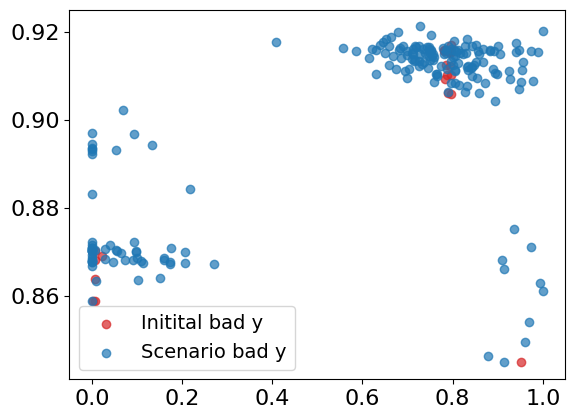

In [285]:
plt.scatter(bad_y, xgb.predict(bad_X), alpha=0.7, label='Initital bad y', color='tab:red')
plt.scatter(bad_y_sc_arr, xgb.predict(best_individuals), alpha=0.7, label='Scenario bad y', color='tab:blue')

plt.legend()
plt.show()

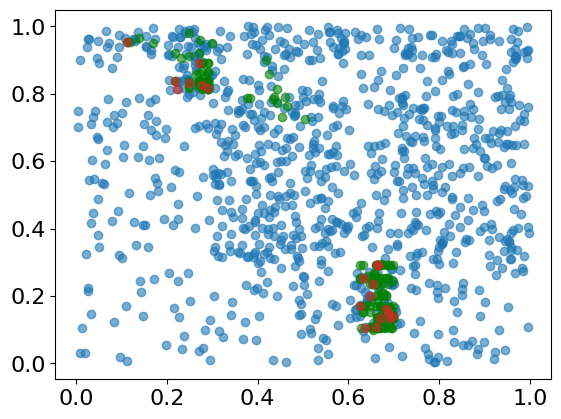

In [286]:
plt.scatter(X_ex.iloc[:, 0], X_ex.iloc[:, 1], alpha=0.6)
plt.scatter(best_individuals[:, 0], best_individuals[:, 1], color='green', alpha=0.6)
plt.scatter(bad_X.iloc[:, 0], bad_X.iloc[:, 1], color='tab:red', alpha=0.6)

plt.show()

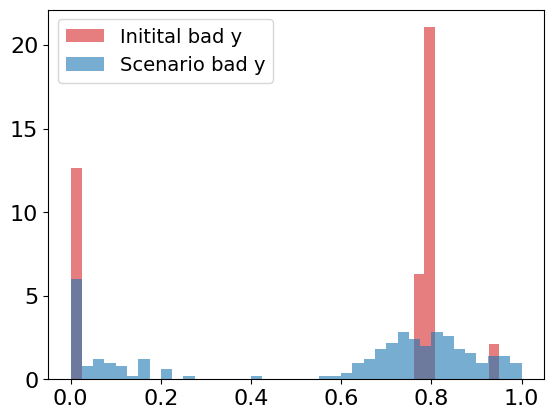

In [287]:
plt.hist(bad_y, bins=40, density=True, alpha=0.6, label='Initital bad y', color='tab:red')
plt.hist(bad_y_sc_arr, bins=40, density=True, alpha=0.6, label='Scenario bad y', color='tab:blue')

plt.legend()
plt.show()

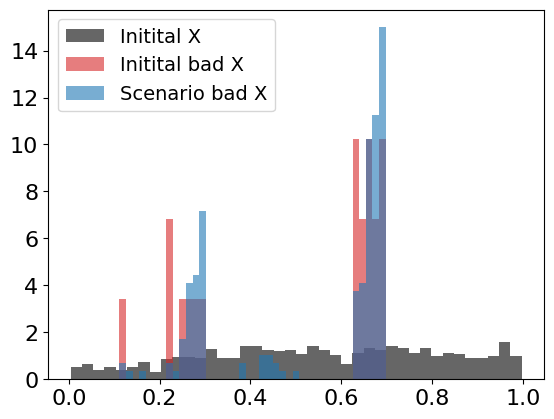

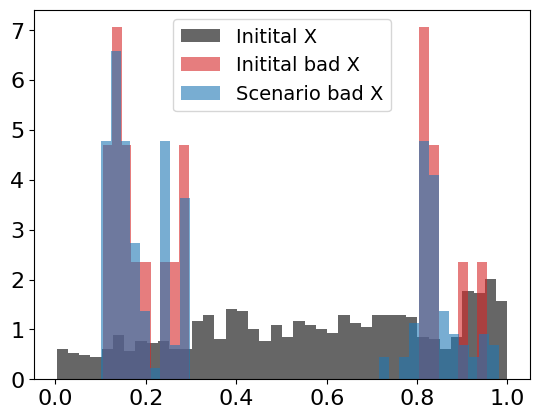

In [288]:
for i in range(len(X_train.columns)):
    plt.hist(X_ex.iloc[:, i], bins=40, alpha=0.6, label='Initital X', color='black', density=True)
    plt.hist(bad_X.iloc[:, i], bins=40, alpha=0.6, label='Initital bad X', color='tab:red', density=True)
    plt.hist(np.array(best_individuals)[:, i], bins=40, alpha=0.6, label='Scenario bad X', color='tab:blue', density=True)

    plt.legend()
    plt.show()

In [408]:
# plt.subplots(figsize=(10, 5))

# vis_arr1 = []
# vis_arr2 = []

# for col in X_exp.columns.values:
#     vis_arr1.append((data.loc[idx_sc, col]/data.loc[idx_sc, col].max()).mean())
#     vis_arr2.append((scenario_df_GA[col]/scenario_df_GA[col].max()).mean())
#     # 
# plt.bar(X_exp.columns, vis_arr1, alpha=0.6, color='tab:blue', label='Initial data')
# plt.bar(X_exp.columns, vis_arr2, alpha=0.6, color='tab:red', label='Synth data')

# plt.xticks(rotation=90, fontsize=10)
# plt.ylabel('Mean value')
# plt.legend()
# plt.show()

In [289]:
bad_X_ga, bad_y_ga = select_bad_examples(pd.DataFrame(best_individuals), pd.DataFrame(bad_y_sc_arr), xgb.predict(best_individuals))

In [290]:
augmented_X = np.concatenate([bad_X.values, bad_X_ga.values])
augmented_y = np.concatenate([bad_y.values.flatten(), bad_y_ga.values.flatten()])

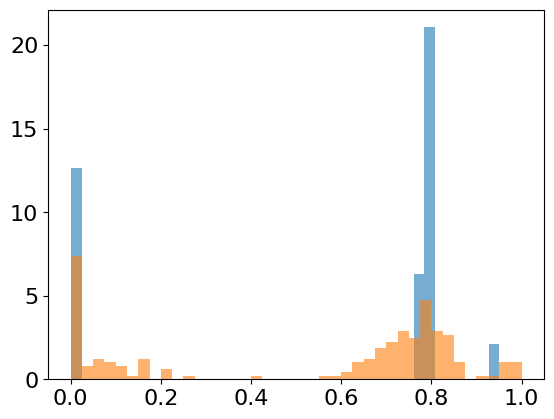

In [291]:
plt.hist(bad_y, density=True, alpha=0.6, bins=40)
plt.hist(augmented_y, bins=40, density=True, alpha=0.6)
plt.show()

In [292]:
augmented__data = np.concatenate([augmented_X, augmented_y.reshape(-1, 1)], axis=1)

In [293]:
augmented__data.shape

(195, 3)

## Generator

In [294]:
# scaler = MinMaxScaler()
# bad_data = scaler.fit_transform(bad_data)
data_tensor = np.array(augmented__data).astype('float32')
data_tensor = torch.tensor(data_tensor)

In [345]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# Residual block
class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super(ResidualBlock, self).__init__()
        self.conv1 = nn.Conv1d(channels, channels, kernel_size=3, padding='same')
        self.bn1 = nn.BatchNorm1d(channels)
        self.conv2 = nn.Conv1d(channels, channels, kernel_size=3, padding='same')
        self.bn2 = nn.BatchNorm1d(channels)
        
        self.act = nn.SiLU()
        
        self.drop1 = nn.Dropout(0.2)
        self.drop2 = nn.Dropout(0.2)

    def forward(self, x):
        skip = x
        out = self.conv1(x)
        out = self.act(out)
        out = out + skip
        out = self.act(out)
        out = self.bn1(out)
        out = self.drop1(out)
        
        skip2 = out
        out = self.conv2(out)
        out = self.act(out)
        out = out + skip2
        out = self.act(out)
        out = self.bn2(out)
        out = self.drop2(out)
        
        return out

# VAE model definition
class VAE(nn.Module):
    def __init__(self, input_channels=1, seq_length=128, latent_dim=16, hidden_channels=32):
        super(VAE, self).__init__()
        self.seq_length = seq_length
        self.latent_dim = latent_dim
        self.hidden_channels = hidden_channels

        
        self.enc_conv1 = nn.Conv1d(input_channels, hidden_channels, kernel_size=3, padding='same')
        self.enc_bn1 = nn.BatchNorm1d(hidden_channels)
        self.enc_res1 = ResidualBlock(hidden_channels)
   
        self.enc_conv2 = nn.Conv1d(hidden_channels, hidden_channels, kernel_size=3, padding='same')
        self.enc_bn2 = nn.BatchNorm1d(hidden_channels)
        self.enc_res2 = ResidualBlock(hidden_channels)

        self.h_dim_enc = seq_length * hidden_channels
        
        self.fc_mu = nn.Sequential(nn.Linear(self.h_dim_enc, latent_dim))
        self.fc_logvar = nn.Sequential(nn.Linear(self.h_dim_enc, latent_dim))
        self.fc_decode = nn.Sequential(nn.Linear(latent_dim, self.h_dim_enc))


        self.dec_conv1 = nn.ConvTranspose1d(hidden_channels, hidden_channels, kernel_size=3, padding=1, output_padding=0)
        self.dec_bn1 = nn.BatchNorm1d(hidden_channels)
        self.dec_res1 = ResidualBlock(hidden_channels)
    
        self.dec_conv2 = nn.ConvTranspose1d(hidden_channels, hidden_channels, kernel_size=3, padding=1, output_padding=0)
        self.dec_res2 = ResidualBlock(hidden_channels)
        self.dec_conv3 = nn.ConvTranspose1d(hidden_channels, input_channels, kernel_size=1)
        
        self.act = nn.SiLU()
        
        self.condition_encoder_beta = nn.Sequential(
            nn.Linear(1, 2**6),
            self.act,
            nn.Linear(2**6, latent_dim),
            self.act
        )
        
        self.condition_encoder_gamma = nn.Sequential(
            nn.Linear(1, 2**6),
            self.act,
            nn.Linear(2**6, latent_dim),
            self.act
        )
        
        self.condition_decoder_beta = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=3, padding='same'),
            self.act,
            nn.Linear(1, 2**6),
            self.act,
            nn.Linear(2**6, 2),
            self.act
        )
        
        self.condition_decoder_gamma = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=3, padding='same'),
            self.act,
            nn.Linear(1, 2**6),
            self.act,
            nn.Linear(2**6, 2),
            self.act
        )

    def encode(self, x, y):
        # skip = x
        x = self.enc_conv1(x)
        
        x = self.act(x)
        # x = self.enc_bn1(x)
        x = self.enc_res1(x)
        
        x = self.enc_conv2(x)
        x = self.act(x)
        # x = self.enc_bn2(x)
        x = self.enc_res2(x)
        
        x = x.view(x.size(0), -1)
        
        mu = self.fc_mu(x) * self.condition_encoder_beta(y).squeeze(1) + self.condition_encoder_gamma(y).squeeze(1)
        logvar = self.fc_logvar(x) * self.condition_encoder_beta(y).squeeze(1) + self.condition_encoder_gamma(y).squeeze(1)
        
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z, y):
        # conv_out_length = (self.seq_length) // 4
        x = self.fc_decode(z)
        
        x = x.view(z.size(0), self.hidden_channels, self.seq_length)
        
        
        x = self.dec_conv1(x)
        
        x = self.act(x)
        # x = self.dec_bn1(x)
        x = self.dec_res1(x)
        
        x = self.dec_conv2(x)
        x = self.dec_res2(x) * self.condition_decoder_beta(y) + self.condition_decoder_gamma(y)
        
        x = self.dec_conv3(x)
        
        
        return x

    def forward(self, x):
        x, y = x[:,:,:-1], x[:,:,-1].unsqueeze(1)
        mu, logvar = self.encode(x, y)
        z = self.reparameterize(mu, logvar)
        recon_x = self.decode(z, y)
        
        return recon_x, mu, logvar

def vae_loss(recon_x, x, mu, logvar, beta):
    recon_loss = F.mse_loss(recon_x, x[:,:,:-1], reduction='mean')
    # kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    kl_loss = torch.mean( -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp() , dim=1) )
    return recon_loss + beta * kl_loss

# Training procedure
def train_vae(model, train_loader, num_epochs=500, learning_rate=1e-3, device=None):
    # if device is None:
        # device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        # device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
        
    model.to(device)
    optimizer = optim.AdamW(model.parameters(), lr=learning_rate)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=2e-4)
    beta_sch = torch.cat([torch.tensor(np.linspace(0.0, 0.0005, num_epochs//2)), torch.tensor(np.linspace(0.0005, 0.01, num_epochs//2))]).float().to(device)
    
    epochs = tqdm(range(num_epochs))
    
    losses = []
    model.train()
    for epoch in epochs:
        epoch_loss = 0
        
        for _, data in enumerate(train_loader):
            data = data.to(device)
            
            recon_data, mu, logvar = model(data)
            loss = vae_loss(recon_data, data, mu, logvar, beta_sch[epoch])
            
            optimizer.zero_grad()
            loss.backward()
            norm = torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1)
            optimizer.step()
        
            epoch_loss += loss.item()
            
        scheduler.step()
        
        
        avg_loss = epoch_loss / len(train_loader.dataset)
        losses.append(avg_loss)
        # print(optimizer.param_groups[0]['lr'])
        if epoch % 100 == 0:
            epochs.set_description(f'Average Loss: {avg_loss:.4f}')
            
    return losses      

In [346]:
batch_size = 2**6
seq_length = len(augmented__data[0]) - 1
input_channels = 1

train_loader = torch.utils.data.DataLoader(data_tensor.unsqueeze(1), batch_size=batch_size, shuffle=True)

# Initialize the VAE model
model_vae = VAE(input_channels=input_channels, seq_length=seq_length, latent_dim=256, hidden_channels=32)

# Train the VAE
losses_vae = train_vae(model_vae, train_loader, num_epochs=1000, learning_rate=1e-3)

  0%|          | 0/1000 [00:00<?, ?it/s]

Average Loss: 0.0003: 100%|██████████| 1000/1000 [01:35<00:00, 10.43it/s]


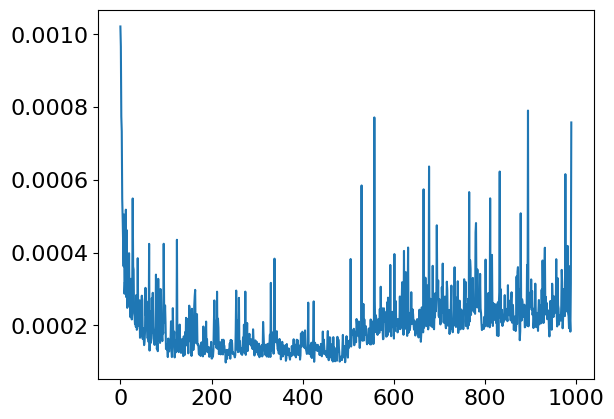

In [347]:
plt.plot(losses_vae[10:])
plt.show()

In [348]:
model_vae.eval()

synth_vae, mu, logvar = model_vae(data_tensor.unsqueeze(1).to(device))
synth_vae = synth_vae.squeeze(1).detach().cpu().numpy()

In [349]:
synth_vae.shape

(195, 2)

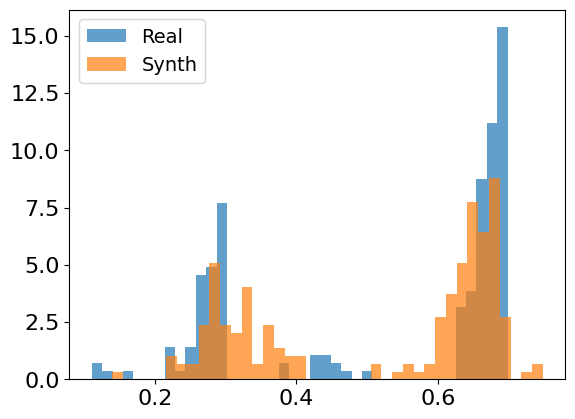

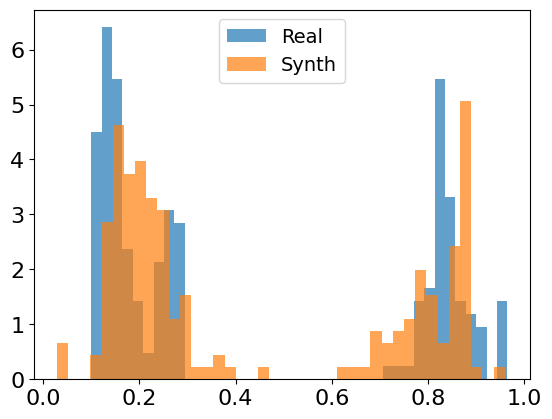

In [351]:
for i in range(0, 2):
    plt.hist(augmented__data[:, i], bins=40, alpha=0.7, density=True, label='Real')
    plt.hist(synth_vae[:, i], bins=40, alpha=0.7, density=True, label='Synth')

    plt.legend()
    plt.show()

In [358]:
# synth_df = pd.DataFrame(np.concatenate([scaler_X_train.inverse_transform(synth_vae[:, :-1]), scaler_y_train.inverse_transform(synth_vae[:, -1].reshape(-1, 1))], axis=1), columns=data.columns)
synth_df = pd.DataFrame(np.concatenate([scaler_X_train.inverse_transform(synth_vae), scaler_y_train.inverse_transform(data_tensor[:, -1].reshape(-1, 1))], axis=1))

In [359]:
# bad_data['pricemetr'].hist(bins=40,  alpha=0.7, density=True)
# synth_df['pricemetr'].hist(bins=40, alpha=0.7, density=True)

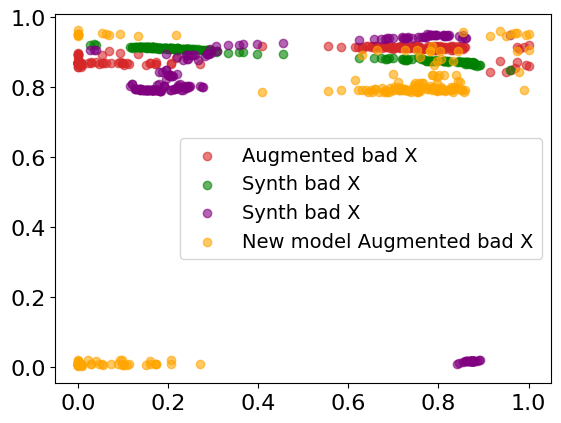

In [360]:
# synth_pred = xgb.predict(synth_df.drop('pricemetr', axis=1))
synth_pred = xgb.predict(synth_df.drop(2, axis=1))
new_model_synth_pred = new_reg_model.predict(synth_df.drop(2, axis=1))

# plt.scatter(bad_y.values, xgb.predict(bad_X), alpha=0.6, label='Real bad X', color='black')
plt.scatter(augmented_y, xgb.predict(augmented_X), alpha=0.6, label='Augmented bad X', color='tab:red')
plt.scatter(synth_vae[:, -1], synth_pred, alpha=0.6, label='Synth bad X', color='green')
plt.scatter(synth_vae[:, -1], new_model_synth_pred, alpha=0.6, label='Synth bad X', color='purple')
plt.scatter(augmented_y, new_reg_model.predict(augmented_X), alpha=0.6, label='New model Augmented bad X', color='orange')


plt.legend()
plt.show()

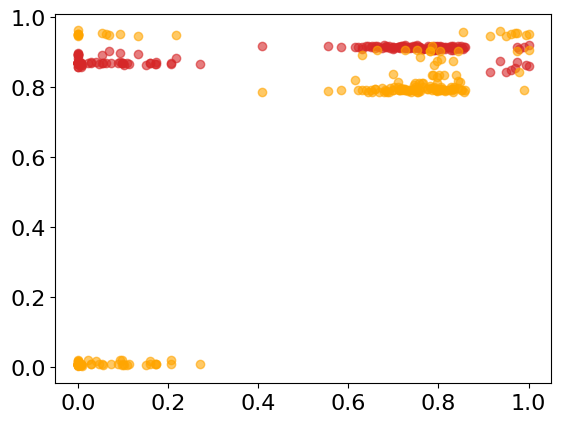

In [ ]:
# plt.scatter(bad_y, xgb.predict(bad_X), alpha=0.6, label='Synth bad X', color='tab:red')
# plt.scatter(bad_y, new_reg_model.predict(bad_X), alpha=0.6, label='Synth bad X', color='orange')

plt.scatter(augmented_y, xgb.predict(augmented_X), alpha=0.6, label='Augmented bad X', color='tab:red')
plt.scatter(augmented_y, new_reg_model.predict(augmented_X), alpha=0.6, label='Synth bad X', color='orange')

plt.show()

In [362]:
mean_squared_error(augmented_y, xgb.predict(augmented_X)), mean_squared_error(augmented_y, new_reg_model.predict(augmented_X))

(0.248516318248421, 0.062284290837630735)

In [375]:
mean_squared_error(bad_y.values.flatten(), xgb.predict(bad_X)), mean_squared_error(bad_y.values.flatten(), new_reg_model.predict(bad_X))

(0.23002283627114836, 0.0021278498013382794)

In [370]:
mean_squared_error(data_tensor[:, -1].numpy(), synth_pred.flatten()), mean_squared_error(data_tensor[:, -1].numpy(), new_model_synth_pred.flatten())

(0.24845867107877026, 0.20369182527065277)

## Distillation

In [ ]:
class RegressionDistill(nn.Module):
    def __init__(self, in_dim):
        super(RegressionDistill, self).__init__()
        
        self.model = nn.Sequential(
            nn.Linear(in_dim, 2**8),
            nn.ReLU(),
            nn.Linear(2**8, 2**8),
            nn.ReLU(),
            nn.Linear(2**8, 1),
        )
        
    def forward(self, x):
        out = self.model(x)
        
        return out

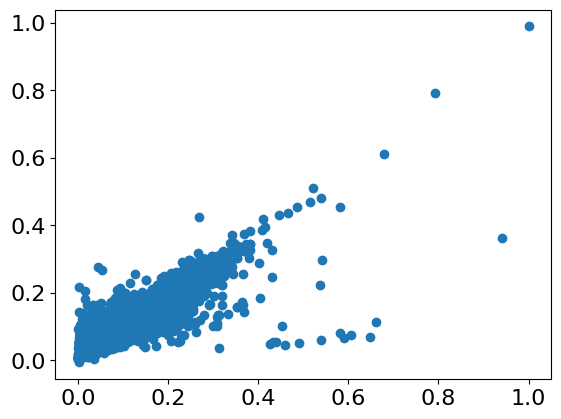

In [ ]:
plt.scatter(data['pricemetr'], xgb.predict(data.drop('pricemetr', axis=1)))

plt.show()

In [ ]:
class DataseCustom(torch.utils.data.Dataset):
    def __init__(self, data, data_distill):
        self.data = data
        self.data_distill = data_distill

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return [self.data[idx], self.data_distill[idx]]

In [ ]:
# scaler_reg = MinMaxScaler()
# data_reg = scaler.fit_transform(data)
data_reg = np.array(data).astype('float32')
data_reg = torch.tensor(data_reg).to(device)

y_for_distill = torch.tensor(xgb.predict(data.drop('pricemetr', axis=1)).reshape(-1, 1)).to(device)

reg_dataset = DataseCustom(data_reg, y_for_distill)
reg_loader = torch.utils.data.DataLoader(reg_dataset, batch_size=256, shuffle=True)

In [ ]:
reg_model = RegressionDistill(X.shape[1]).to(device)
optim_reg = optim.AdamW(reg_model.parameters(), lr=3e-4)

epochs = tqdm(range(100))

for _ in epochs:
    for data_x, data_d in reg_loader:
        
        reg_pred = reg_model(data_x[:, :-1])
        
        loss = 0.1 * torch.mean( (reg_pred - data_x[:, -1])**2 ) + torch.mean( (reg_pred - data_d)**2 )
        
        optim_reg.zero_grad()
        loss.backward()
        optim_reg.step()
        
    epochs.set_description(f'{loss.item()}')

0.00018467020709067583: 100%|██████████| 100/100 [03:03<00:00,  1.84s/it]


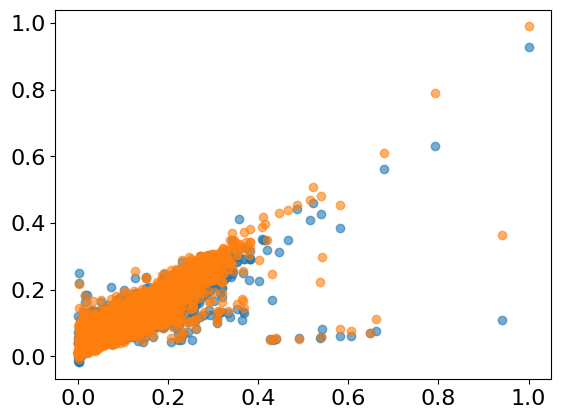

In [ ]:
plt.scatter(y_train.values, reg_model(torch.tensor(X_train.values.astype('float32')).to(device)).detach().cpu().numpy().T[0], alpha=0.6)
plt.scatter(y_train.values, xgb.predict(X_train), alpha=0.6)

plt.show()

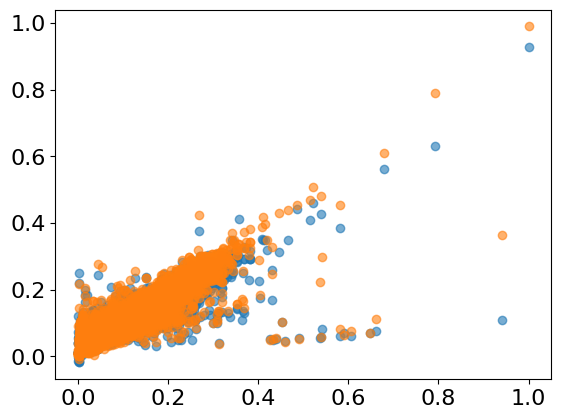

In [ ]:
plt.scatter(data['pricemetr'].values, reg_model(torch.tensor(data.drop('pricemetr', axis=1).values.astype('float32')).to(device)).detach().cpu().numpy().T[0], alpha=0.6)
plt.scatter(data['pricemetr'].values, xgb.predict(data.drop('pricemetr', axis=1)), alpha=0.6)

plt.show()

In [ ]:
mean_absolute_percentage_error(y_test.values, xgb.predict(X_test))

0.08490533088485587

In [ ]:
mean_absolute_percentage_error(y_test.values, reg_model(torch.tensor(X_test.values.astype('float32')).to(device)).detach().cpu().numpy().T[0])

0.09439399900230046

## Generate synth with regression loss

In [ ]:
reg_model.eval()
reg_model.train(False)

RegressionDistill(
  (model): Sequential(
    (0): Linear(in_features=26, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=1, bias=True)
  )
)

In [ ]:
def vae_loss(recon_x, x, mu, logvar, beta, reg_model):
    recon_loss = F.mse_loss(recon_x, x, reduction='mean')
    # kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    kl_loss = torch.mean( -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp() , dim=1) )
    
    reg_pred_synth = reg_model(recon_x.squeeze(1)[:, :-1])
    # reg_pred = reg_model(x.squeeze(1)[:, :-1])
    
    err_ml_synth = torch.mean( (reg_pred_synth - x.squeeze(1)[:, -1].unsqueeze(1))**2 )
    # err_ml = torch.mean( (reg_pred - x.squeeze(1)[:, -1])**2 )
    
    # ml_loss = (err_ml_synth - err_ml)**2
    ml_loss = err_ml_synth
    
    return recon_loss + beta * kl_loss + 2 * ml_loss


def train_vae(model, train_loader, reg_model, num_epochs=500, learning_rate=1e-3, device=None):
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        # device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
        
    model.to(device)
    optimizer = optim.AdamW(model.parameters(), lr=learning_rate)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=2e-4)
    beta_sch = torch.cat([torch.tensor(np.linspace(0.0, 0.0005, num_epochs//2)), torch.tensor(np.linspace(0.0005, 0.001, num_epochs//2))]).float().to(device)
    
    epochs = tqdm(range(num_epochs))
    
    losses = []
    model.train()
    for epoch in epochs:
        epoch_loss = 0
        
        for _, data in enumerate(train_loader):
            data = data.to(device)
            
            recon_data, mu, logvar = model(data)
            
            loss = vae_loss(recon_data, data, mu, logvar, beta_sch[epoch], reg_model)
            
            optimizer.zero_grad()
            loss.backward()
            norm = torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1)
            optimizer.step()
        
            epoch_loss += loss.item()
            
        scheduler.step()
        
        
        avg_loss = epoch_loss / len(train_loader.dataset)
        losses.append(avg_loss)
        # print(optimizer.param_groups[0]['lr'])
        if epoch % 100 == 0:
            epochs.set_description(f'Average Loss: {avg_loss:.4f}')
            
    return losses 

In [ ]:
batch_size = 2**3
seq_length = 27
input_channels = 1

train_loader = torch.utils.data.DataLoader(data_tensor.unsqueeze(1), batch_size=batch_size, shuffle=True)

# Initialize the VAE model
model_vae = VAE(input_channels=input_channels, seq_length=seq_length, latent_dim=128, hidden_channels=32)

# Train the VAE
losses_vae = train_vae(model_vae, train_loader, reg_model, num_epochs=1000, learning_rate=2e-3)

Average Loss: 0.0026: 100%|██████████| 1000/1000 [04:05<00:00,  4.08it/s]


In [ ]:
model_vae.eval()

synth_vae, mu, logvar = model_vae(data_tensor.unsqueeze(1).to(device))
synth_vae = synth_vae.squeeze(1).detach().cpu().numpy()

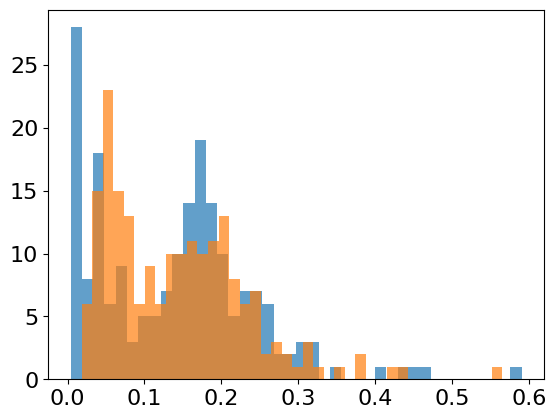

In [ ]:
plt.hist(bad_data.values[:, -1], bins=40, alpha=0.7)
plt.hist(synth_vae[:, -1], bins=40, alpha=0.7)

plt.show()

In [ ]:
synth_df = pd.DataFrame(synth_vae, columns=data.columns)

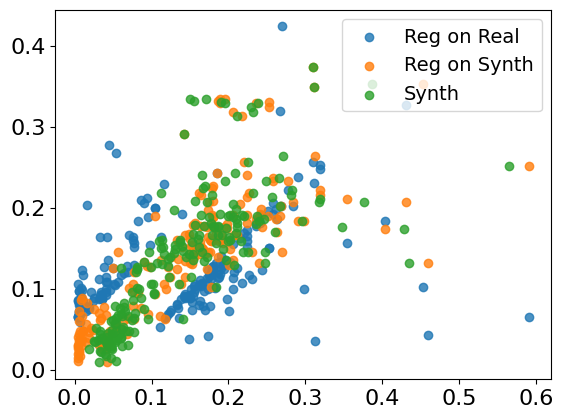

In [ ]:
synth_pred = xgb.predict(synth_df.drop('pricemetr', axis=1))
# synth_pred = reg_model(torch.tensor(synth_df.drop('pricemetr', axis=1).values.astype('float32')).to(device)).detach().cpu().numpy().T[0]

plt.scatter(bad_y.values, xgb.predict(bad_X), alpha=0.8, label='Reg on Real')
plt.scatter(bad_y.values, synth_pred, alpha=0.8, label='Reg on Synth')
plt.scatter(synth_df.iloc[:, -1].values, synth_pred, alpha=0.8, label='Synth')

plt.legend()
plt.show()

In [ ]:
mean_absolute_percentage_error(bad_y.values, xgb.predict(bad_X))

2.3421116556985595

In [ ]:
mean_absolute_percentage_error(bad_y.values, synth_pred)

0.9466585264171131

## Значимость до и после

In [ ]:
import shap

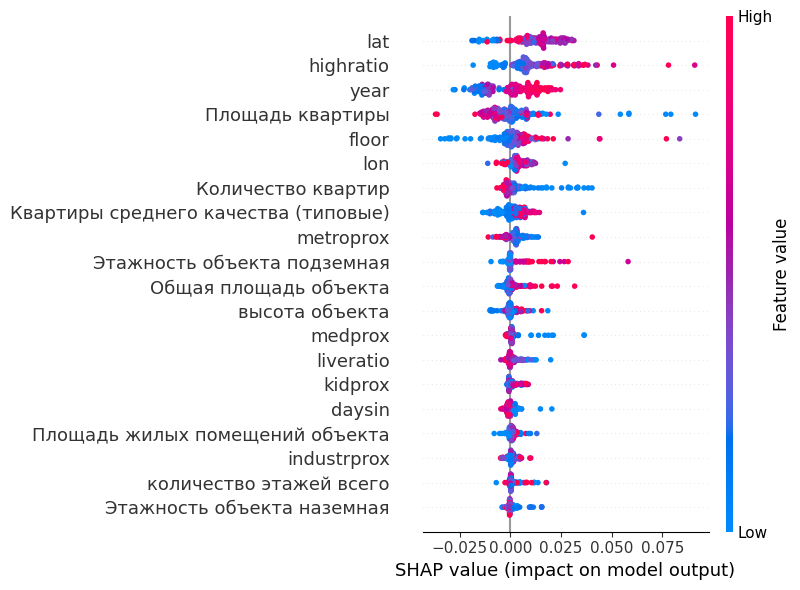

In [ ]:
explainer = shap.TreeExplainer(xgb)
explanation = explainer(bad_X)
shap.summary_plot(explanation, plot_size=[8,6])

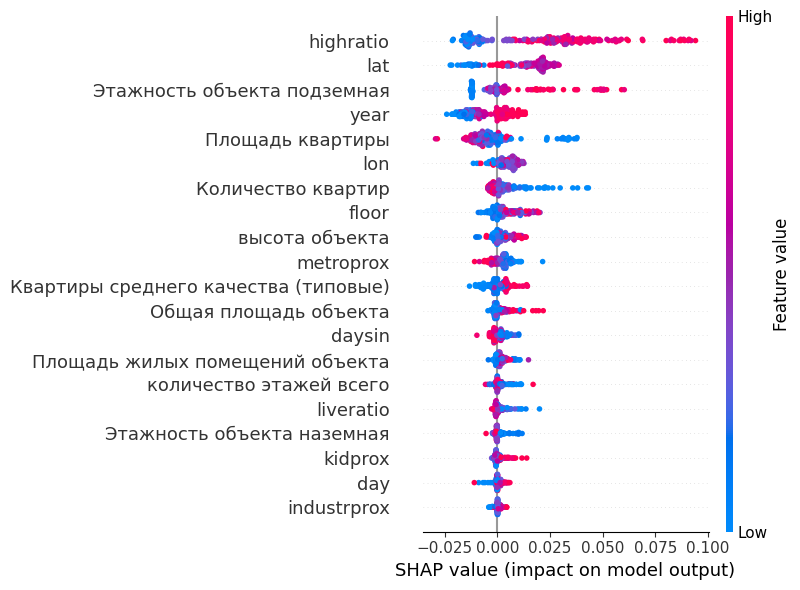

In [ ]:
explainer = shap.TreeExplainer(xgb)
explanation = explainer(synth_df.drop('pricemetr', axis=1))
shap.summary_plot(explanation, plot_size=[8,6])

In [ ]:
X_test

,Площадь квартиры,day,количество этажей всего,высота объекта,Этажность объекта подземная,Этажность объекта наземная,Количество квартир,Общая площадь объекта,Площадь жилых помещений объекта,lon,...,kidprox,schoolprox,cemetprox,industrprox,daysin,daycos,liveratio,highratio,month,year
197843,0.078628,0.933333,0.166667,0.105369,0.043478,0.162791,0.543039,0.378770,0.513668,0.317873,...,0.180276,1.000000,0.712078,0.348210,0.000222,0.484930,0.519744,0.017016,0.727273,0.714286
241365,0.177332,0.066667,0.177778,0.113453,0.043478,0.174419,0.398578,0.171181,0.334381,0.406764,...,0.295473,0.161008,0.262591,0.323761,0.478489,0.000444,0.843107,0.016169,0.545455,1.000000
20316,0.122543,0.000000,0.266667,0.177507,0.043478,0.267442,0.144835,0.069355,0.108658,0.573182,...,0.075609,0.174620,0.400346,0.008439,0.064143,0.254972,0.645087,0.011772,0.727273,0.857143
130110,0.118779,0.233333,0.255556,0.176643,0.043478,0.267442,0.212575,0.129392,0.245033,0.281815,...,0.107522,0.081940,0.301690,0.006275,0.104524,0.805940,0.811942,0.011549,0.909091,0.142857
195371,0.086156,1.000000,0.122222,0.135761,0.086957,0.104651,0.117515,0.090403,0.118923,0.326836,...,0.057479,0.075098,0.357938,0.092152,0.066268,0.748752,0.510352,0.067626,0.818182,0.285714
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
179088,0.095776,0.866667,0.366667,0.259642,0.043478,0.372093,0.534431,0.266896,0.483290,0.525481,...,0.209349,0.295370,0.480276,0.031226,0.951682,0.285541,0.765897,0.011263,0.272727,0.857143
239930,0.179423,0.433333,0.177778,0.113453,0.043478,0.174419,0.398578,0.171181,0.334381,0.406764,...,0.295473,0.161008,0.262591,0.323761,0.393239,0.011512,0.843107,0.016169,0.545455,0.714286
148808,0.288582,0.733333,0.500000,0.434557,0.086957,0.500000,0.248877,0.206435,0.306093,0.467330,...,0.290879,0.056122,0.579471,0.028749,0.036225,0.686854,0.590757,0.021409,0.818182,0.000000
222245,0.184023,0.933333,0.188889,0.112928,0.043478,0.186047,0.070359,0.031170,0.053273,0.346693,...,0.073238,0.091147,0.128909,0.116979,0.521511,0.000444,0.730038,0.012286,0.454545,0.714286


In [ ]:
pd.DataFrame(y_test)

,pricemetr
197843,0.045481
241365,0.056046
20316,0.074643
130110,0.063613
195371,0.052921
...,...
179088,0.089180
239930,0.074902
148808,0.072743
222245,0.075214


## Create regression model on the whole dataset

In [ ]:
mean_absolute_percentage_error(y_test.values, reg_model(torch.tensor(X_test.values.astype('float32')).to(device)).detach().cpu().numpy().T[0])

0.09439399900230046

In [ ]:
data_best = data.drop(data.loc[y_test.iloc[idx_bad].index].index)
data_best = pd.concat([data_best, synth_df])
# data_best = pd.DataFrame(scaler.inverse_transform(data_best), columns=data_best.columns)

In [ ]:
X_best, y_best = data_best.drop('pricemetr', axis=1), data_best['pricemetr']

xgb_best = XGBRegressor()

train(X_best, y_best, xgb_best)

{'mape_mean': 1382272032.462,
 'mape_std': 2764544064.7441,
 'r2_mean': 0.876,
 'r2_std': 0.0109}

In [ ]:
xgb_best.fit(X_best, y_best)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

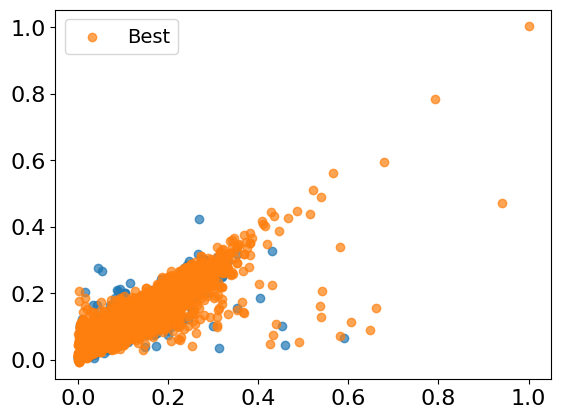

In [ ]:
plt.scatter(y_test.values, xgb_pred, alpha=0.7)
# plt.scatter(y_test.values, reg_model(torch.tensor(X_test.values.astype('float32')).to(device)).detach().cpu().numpy().T[0])
plt.scatter(y_best.values, xgb_best.predict(X_best), alpha=0.7, label='Best')

plt.legend()
plt.show()

In [ ]:
data_test = pd.DataFrame(scaler.inverse_transform(data), columns=data.columns).loc[X_test.index]

In [ ]:
X_test

,Площадь квартиры,day,количество этажей всего,высота объекта,Этажность объекта подземная,Этажность объекта наземная,Количество квартир,Общая площадь объекта,Площадь жилых помещений объекта,lon,...,kidprox,schoolprox,cemetprox,industrprox,daysin,daycos,liveratio,highratio,month,year
197843,0.078628,0.933333,0.166667,0.105369,0.043478,0.162791,0.543039,0.378770,0.513668,0.317873,...,0.180276,1.000000,0.712078,0.348210,0.000222,0.484930,0.519744,0.017016,0.727273,0.714286
241365,0.177332,0.066667,0.177778,0.113453,0.043478,0.174419,0.398578,0.171181,0.334381,0.406764,...,0.295473,0.161008,0.262591,0.323761,0.478489,0.000444,0.843107,0.016169,0.545455,1.000000
20316,0.122543,0.000000,0.266667,0.177507,0.043478,0.267442,0.144835,0.069355,0.108658,0.573182,...,0.075609,0.174620,0.400346,0.008439,0.064143,0.254972,0.645087,0.011772,0.727273,0.857143
130110,0.118779,0.233333,0.255556,0.176643,0.043478,0.267442,0.212575,0.129392,0.245033,0.281815,...,0.107522,0.081940,0.301690,0.006275,0.104524,0.805940,0.811942,0.011549,0.909091,0.142857
195371,0.086156,1.000000,0.122222,0.135761,0.086957,0.104651,0.117515,0.090403,0.118923,0.326836,...,0.057479,0.075098,0.357938,0.092152,0.066268,0.748752,0.510352,0.067626,0.818182,0.285714
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
179088,0.095776,0.866667,0.366667,0.259642,0.043478,0.372093,0.534431,0.266896,0.483290,0.525481,...,0.209349,0.295370,0.480276,0.031226,0.951682,0.285541,0.765897,0.011263,0.272727,0.857143
239930,0.179423,0.433333,0.177778,0.113453,0.043478,0.174419,0.398578,0.171181,0.334381,0.406764,...,0.295473,0.161008,0.262591,0.323761,0.393239,0.011512,0.843107,0.016169,0.545455,0.714286
148808,0.288582,0.733333,0.500000,0.434557,0.086957,0.500000,0.248877,0.206435,0.306093,0.467330,...,0.290879,0.056122,0.579471,0.028749,0.036225,0.686854,0.590757,0.021409,0.818182,0.000000
222245,0.184023,0.933333,0.188889,0.112928,0.043478,0.186047,0.070359,0.031170,0.053273,0.346693,...,0.073238,0.091147,0.128909,0.116979,0.521511,0.000444,0.730038,0.012286,0.454545,0.714286


In [ ]:
data_test = pd.DataFrame(scaler.transform(data_test), columns=data.columns)

In [ ]:
num_parts = 50

In [ ]:
def separate_test(data_test: pd.DataFrame, num_parts=50):
    block_len = len(data_test) // num_parts
    
    X_parts = []
    y_parts = []
    
    for i in range(num_parts):
        X_parts.append(data_test.iloc[block_len * i : block_len*(i+1)].drop('pricemetr', axis=1))
        y_parts.append(data_test.iloc[block_len * i : block_len*(i+1)]['pricemetr'])
        
    return X_parts, y_parts

In [ ]:
X_partition, y_partition = separate_test(data_test)

In [ ]:
def calc_partition_errors(X_partition, y_partition):
    errors_part = []
    for i in range(len(X_partition)):
        errors_part.append(mean_absolute_percentage_error(y_partition[i], xgb.predict(X_partition[i])))
        
    return np.array(errors_part), np.mean(errors_part)

In [ ]:
errors_part, mean_errors_part = calc_partition_errors(X_partition, y_partition)

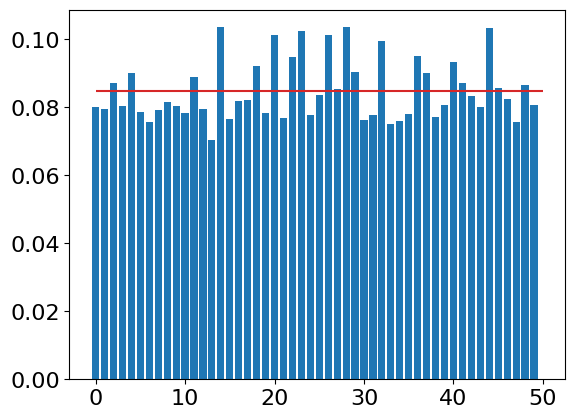

In [ ]:
plt.bar(np.arange(num_parts), errors_part)
plt.hlines(y=mean_errors_part, xmin=0, xmax=num_parts, color='tab:red')

plt.show()

In [ ]:
bad_parts = np.where(errors_part > mean_errors_part)[0]

In [ ]:
np.vstack(np.array(X_partition)[bad_parts]).shape

(20120, 26)

In [ ]:
np.vstack(np.array(y_partition)[bad_parts].reshape(-1, 1)).shape

(20120, 1)

In [ ]:
bad_data

,Площадь квартиры,day,количество этажей всего,высота объекта,Этажность объекта подземная,Этажность объекта наземная,Количество квартир,Общая площадь объекта,Площадь жилых помещений объекта,lon,...,schoolprox,cemetprox,industrprox,daysin,daycos,liveratio,highratio,month,year,pricemetr
184100,0.077373,0.800000,0.188889,0.120673,0.086957,0.174419,0.113772,0.086875,0.146762,0.461956,...,0.104177,0.648542,0.070067,0.002443,0.450580,0.706418,0.018962,0.727273,0.857143,0.032233
70615,0.335843,0.166667,0.122222,0.105862,0.043478,0.116279,0.068862,0.163161,0.190317,0.643672,...,0.254370,0.489058,0.053416,0.206105,0.095475,0.423622,0.040420,0.636364,1.000000,0.284373
86785,0.232037,0.633333,0.133333,0.086856,0.043478,0.127907,0.493638,0.486907,0.668405,0.614430,...,0.070007,0.417202,0.026202,0.990658,0.596218,0.527879,0.023366,0.181818,0.428571,0.007365
126845,0.082392,0.433333,0.533333,0.447701,0.043478,0.546512,0.486153,0.277586,0.468440,0.415072,...,0.119457,0.414187,0.077307,0.020637,0.357809,0.699499,0.017438,0.727273,0.714286,0.164793
109929,0.139691,0.366667,0.533333,0.499229,0.130435,0.523256,0.450225,0.417946,0.652225,0.481515,...,0.157367,0.494876,0.018904,0.025815,0.341392,0.629889,0.027155,0.727273,0.857143,0.235613
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
118574,0.402593,0.500000,0.166667,0.118482,0.086957,0.151163,0.204716,0.245708,0.346820,0.452181,...,0.157541,0.828643,0.141792,0.861825,0.845084,0.551561,0.027356,0.090909,0.857143,0.179174
203160,0.123798,0.166667,0.177778,0.105523,0.086957,0.174419,0.485404,0.347218,0.482521,0.268395,...,0.169122,0.331765,0.193070,0.291401,0.954408,0.538188,0.013101,1.000000,0.142857,0.458963
70705,0.257633,0.933333,0.355556,0.308855,0.043478,0.372093,0.233907,0.270350,0.439303,0.632686,...,0.189081,0.591401,0.058112,0.264418,0.058959,0.665892,0.020494,0.545455,1.000000,0.252872
80283,0.172104,0.633333,0.311111,0.234897,0.086957,0.302326,0.450599,0.343383,0.546531,0.588096,...,0.135268,0.413689,0.023993,0.027197,0.662665,0.647190,0.018445,0.818182,0.571429,0.167712
